# Logistic Regression From Scratch
### Logistic regression is a supervised machine learning algorithm used for classification problems, especially when the output is binary (e.g., yes/no, spam/not spam, disease/no disease). Even though it’s called regression, it’s actually used for predicting categories, not continuous values.

### Logistic regression predicts the probability that an input belongs to a certain class.

### Instead of giving a direct output, it outputs a value between 0 and 1 using a special function called the sigmoid (logistic) function:
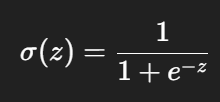

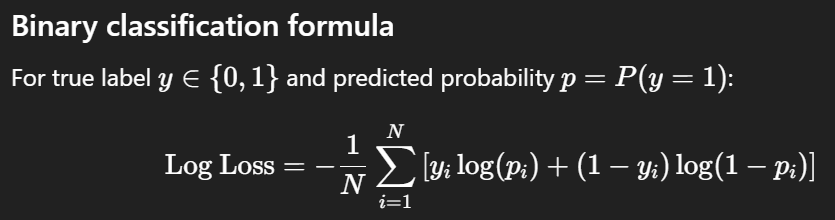

In [6]:
# Importing Modules
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Generating Dataset
X, y = make_classification(n_samples=100, n_features = 2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, hypercube=False, random_state=41, class_sep=10)

In [8]:
# Shape of the Data
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (100, 2)
Shape of y: (100,)


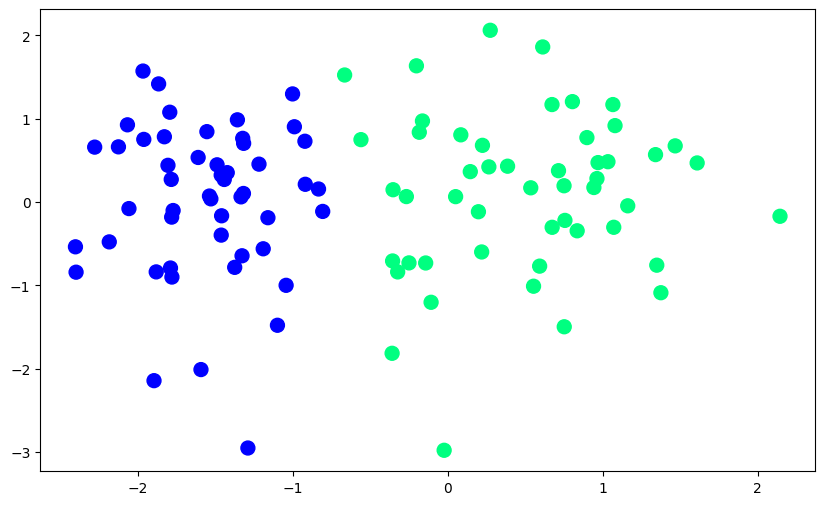

In [9]:
# Plotting the generated data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

In [10]:
#Basic Logistic Regression Model From Scratch
class LogisticReg:
  def __init__(self, lr=0.01, epochs=1000):
    self.lr = lr;
    self.epochs = epochs
    self.w = None
    self.b = None
  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def fit(self, X, y):
    self.w = np.zeros(X.shape[1])
    self.b = 0

    for i in range(self.epochs):
      z = np.dot(X, self.w) + self.b
      y_pred = self.sigmoid(z)
      dw = np.dot(X.T, (y_pred - y)) / X.shape[0]
      db = np.sum(y_pred - y) / X.shape[0]
      self.w -= self.lr*dw
      self.b -= self.lr*db

  def predict(self, X):
    z = np.dot(X, self.w) + self.b
    y_pred = self.sigmoid(z)
    return np.array([1 if i>0.5 else 0 for i in y_pred])


In [11]:
# Testing Our Model
model = LogisticReg(lr=0.1, epochs=2000)
model.fit(X, y)

preds = model.predict(X)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y, preds))

Accuracy: 0.99


In [12]:
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 8],
    [8, 8]
])

y = np.array([0, 0, 0, 1, 1, 1])

model = LogisticReg(lr=0.1, epochs=1000)
model.fit(X, y)

preds = model.predict(X)
print("Predictions:", preds)
print("Actual:", y)

Predictions: [0 0 0 1 1 1]
Actual: [0 0 0 1 1 1]


# Logistic Regression — Perceptron Style

In [13]:
# Logistic Regression - Perceptron Style
"""
for i in range(epochs):
      randomly pick a point
      check the error
      update weights

But instead of a hard step function, we use sigmoid.
Instead of updating ONLY on wrong predictions,
we update on EVERY point — proportional to the error.
"""

class LogisticRegSGD():
  def __init__(self, lr, epochs):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = 0

  def sigmoid(self, z):
    return (1 / (1 + np.exp(-z)))

  def fit(self, X, y):
    m, n = X.shape
    self.w = np.zeros(n)
    for i in range(self.epochs):
      j = np.random.randint(0, m)
      xi = X[j]
      yi = y[j]
      z = np.dot(xi, self.w) + self.b
      y_hat = self.sigmoid(z)
      error = yi - y_hat
      self.w = self.w + self.lr * error * xi
      self.b = self.b + self.lr * error

  def predict(self, X_test):
    z = np.dot(X_test, self.w) + self.b
    prob = self.sigmoid(z)
    return np.array([1 if i > 0.5 else 0 for i in prob])


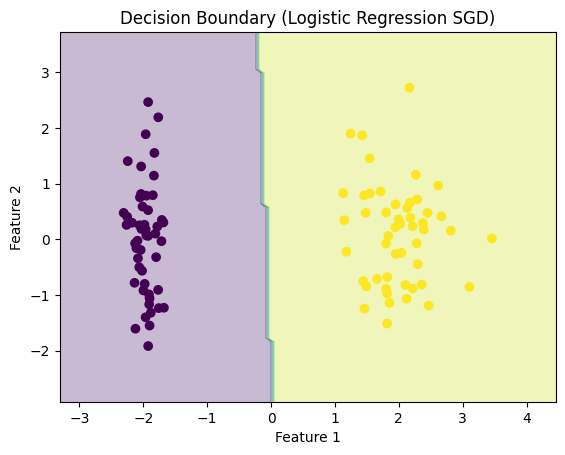

In [17]:
# Generate dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
    class_sep=2
)

# Train model
model = LogisticRegSGD(lr=0.1, epochs=5000)
model.fit(X, y)

# Plot decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Decision Boundary (Logistic Regression SGD)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(X, y, model)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Test Accuracy:", np.mean(preds == y_test))

Test Accuracy: 1.0
